# 03 — Seasonality & Anomaly Detection
**Question:** How should fleet size scale seasonally, and which months are statistically anomalous?

Key findings: 3× summer vs winter swing; COVID 2020 duration spike; Sep 2022 Queen's death dip.

In [4]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

PROJECT = 'm2-dataset-study'

client = bigquery.Client(project=PROJECT)

def bq(sql):
    return client.query(sql, location='EU').to_dataframe()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['figure.titlesize'] = 28
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlepad'] = 20

## 3.1 — Monthly rental volume with anomaly bands

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


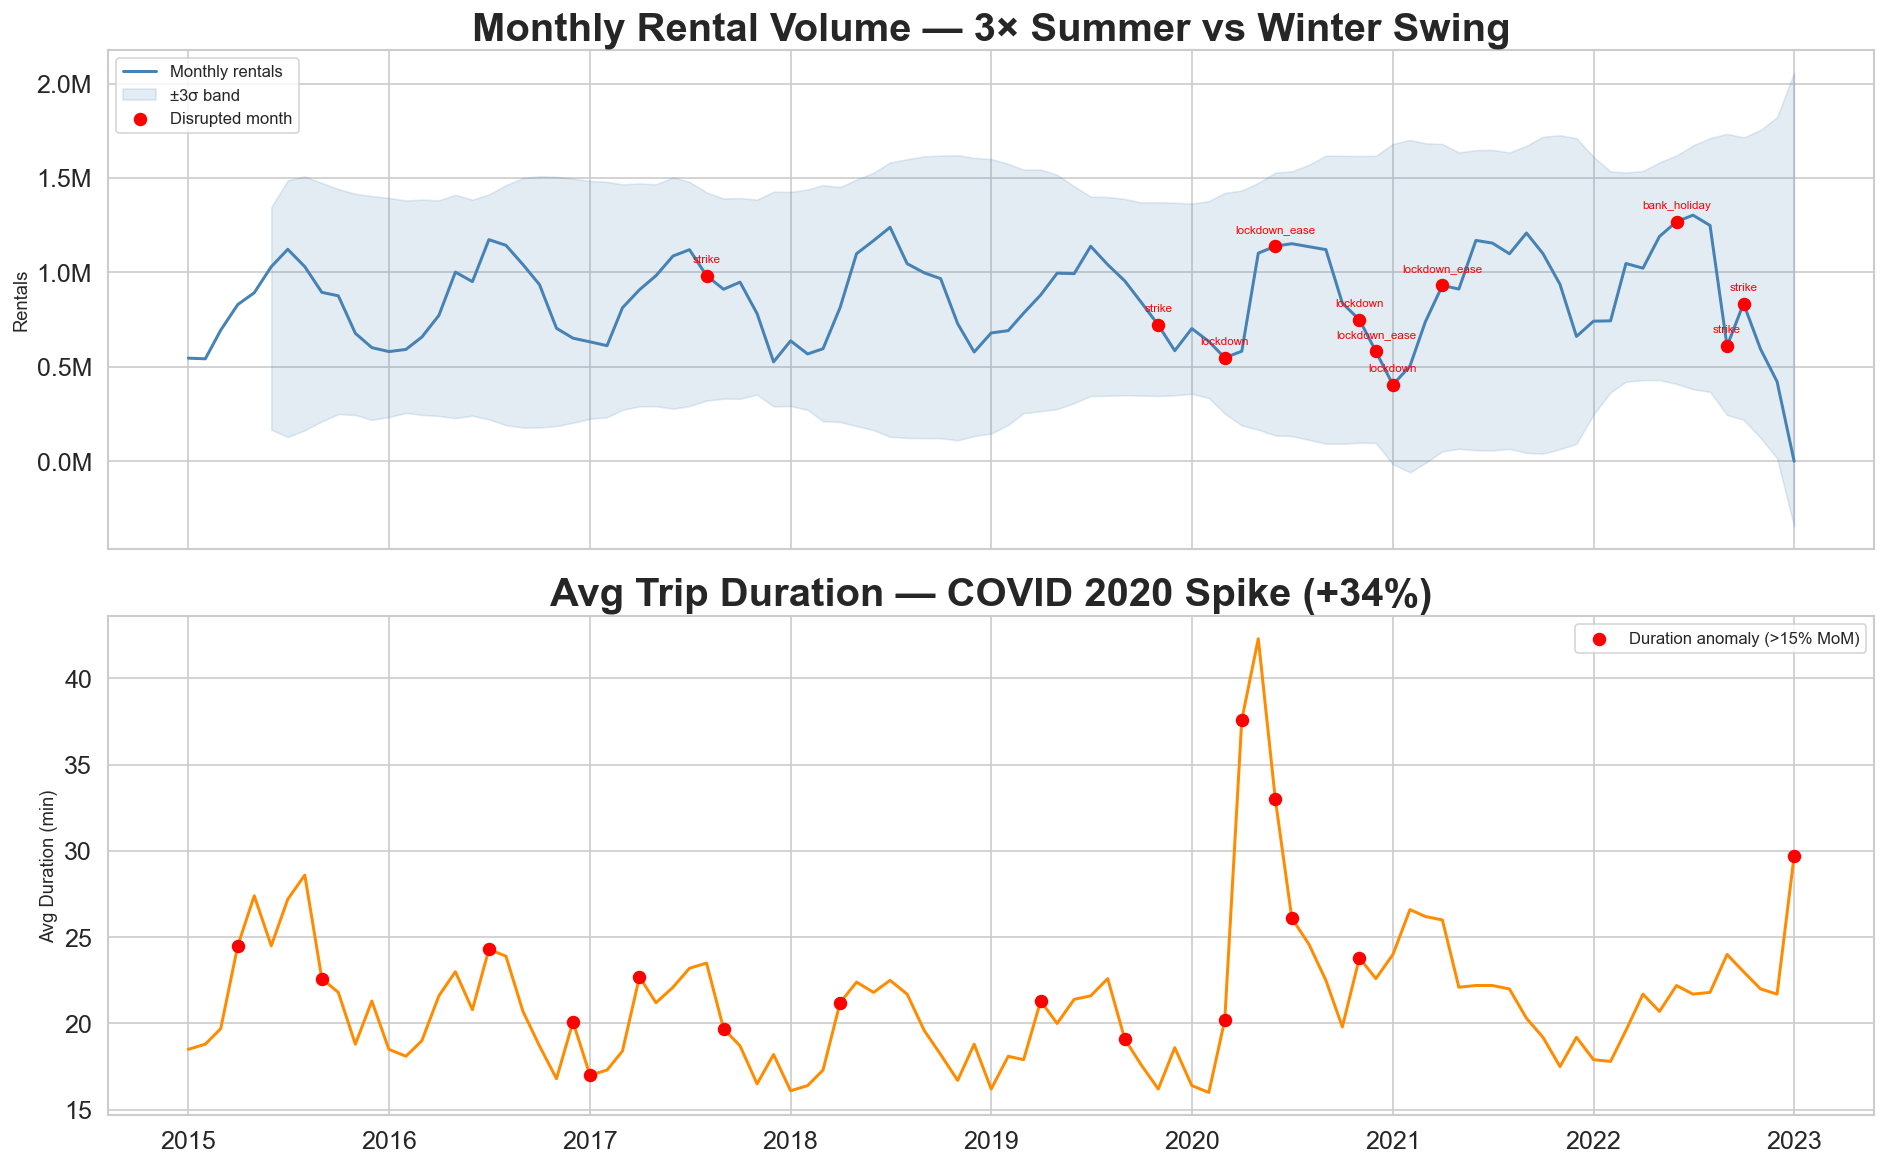

In [7]:
sql = """
SELECT
    month_start,
    year,
    month,
    total_rentals,
    avg_duration_min,
    is_disrupted_month,
    disruption_type,
    duration_anomaly_flag,
    mom_rental_change_pct
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_monthly_trends`
ORDER BY month_start
"""
df = bq(sql)
df['month_start'] = pd.to_datetime(df['month_start'])

# 3-sigma bands on rolling 12-month window
df['rolling_mean'] = df['total_rentals'].rolling(12, min_periods=6).mean()
df['rolling_std']  = df['total_rentals'].rolling(12, min_periods=6).std()
df['upper_3sigma'] = df['rolling_mean'] + 3 * df['rolling_std']
df['lower_3sigma'] = df['rolling_mean'] - 3 * df['rolling_std']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: rental volume
ax = axes[0]
ax.plot(df['month_start'], df['total_rentals'], color='steelblue', linewidth=1.8, label='Monthly rentals')
ax.fill_between(df['month_start'], df['lower_3sigma'], df['upper_3sigma'],
                alpha=0.15, color='steelblue', label='±3σ band')
disrupted = df[df['is_disrupted_month'] == True]
ax.scatter(disrupted['month_start'], disrupted['total_rentals'],
           color='red', zorder=5, s=50, label='Disrupted month')
for _, row in disrupted.iterrows():
    ax.annotate(row['disruption_type'], (row['month_start'], row['total_rentals']),
                textcoords='offset points', xytext=(0, 8), fontsize=7,
                ha='center', color='red')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_ylabel('Rentals', fontsize=11)
ax.set_title('Monthly Rental Volume — 3× Summer vs Winter Swing', fontsize=24, fontweight='bold')
ax.legend(fontsize=10)

# Bottom: average duration (COVID spike visible)
ax2 = axes[1]
ax2.plot(df['month_start'], df['avg_duration_min'], color='darkorange', linewidth=1.8)
anomalies = df[df['duration_anomaly_flag'] == True]
ax2.scatter(anomalies['month_start'], anomalies['avg_duration_min'],
            color='red', zorder=5, s=50, label='Duration anomaly (>15% MoM)')
ax2.set_ylabel('Avg Duration (min)', fontsize=11)
ax2.set_title('Avg Trip Duration — COVID 2020 Spike (+34%)', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/03_seasonality.png', bbox_inches='tight')
plt.show()

## 3.2 — Year-over-year annual KPIs

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


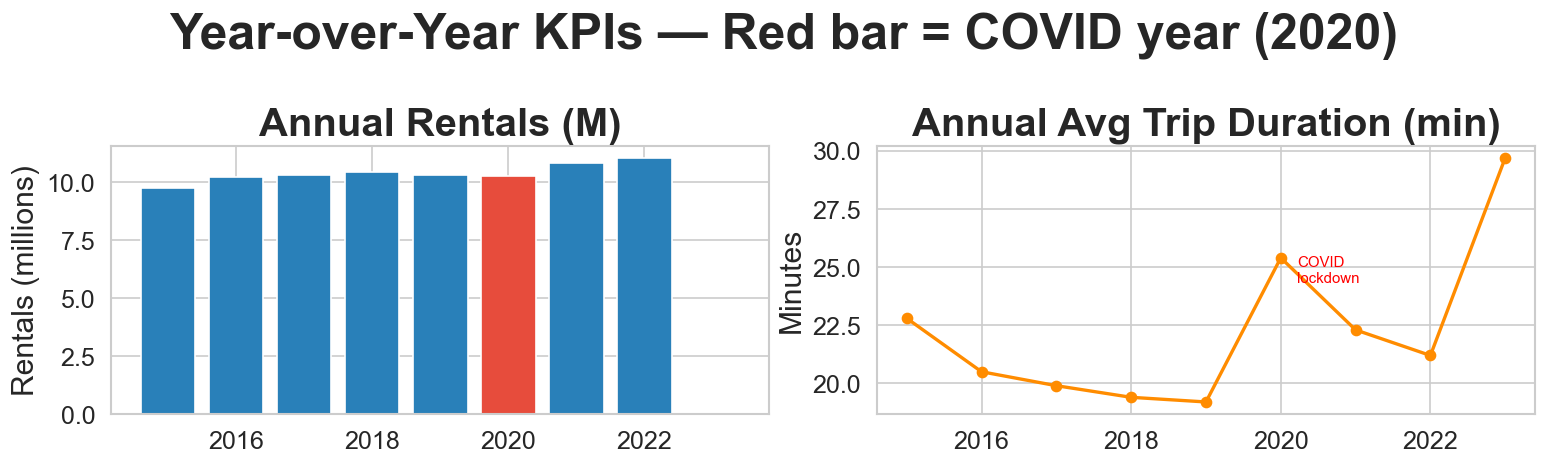

 year  total_rentals  avg_duration_min  unique_bikes
 2015        9738926              22.8        134835
 2016       10207262              20.5        138662
 2017       10306271              19.9        138394
 2018       10441884              19.4        135389
 2019       10310063              19.2        131429
 2020       10287040              25.4        134874
 2021       10821289              22.3        137854
 2022       11027273              21.2        150039
 2023              4              29.7             4


In [8]:
yoy_sql = """
SELECT
    year,
    SUM(total_rentals)            AS total_rentals,
    ROUND(AVG(avg_duration_min),1) AS avg_duration_min,
    SUM(unique_bikes)             AS unique_bikes
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_monthly_trends`
GROUP BY year
ORDER BY year
"""
yoy = bq(yoy_sql)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(yoy['year'], yoy['total_rentals'] / 1e6,
            color=['#E74C3C' if y == 2020 else '#2980B9' for y in yoy['year']])
axes[0].set_title('Annual Rentals (M)', fontweight='bold')
axes[0].set_ylabel('Rentals (millions)')

axes[1].plot(yoy['year'], yoy['avg_duration_min'], marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Annual Avg Trip Duration (min)', fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].annotate('COVID\nlockdown', (2020, yoy.loc[yoy.year==2020,'avg_duration_min'].values[0]),
                 textcoords='offset points', xytext=(10, -15), color='red', fontsize=9)

plt.suptitle('Year-over-Year KPIs — Red bar = COVID year (2020)', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_yoy_kpis.png', bbox_inches='tight')
plt.show()
print(yoy.to_string(index=False))